# Notebook 3: Evaluation & Results

**Course:** M7016H — Artificial Intelligence within the Healthcare System
**Dataset:** Pima Indians Diabetes Dataset (Dataset 4)
**Authors:** Jamshaid Amjad, Shameena Mohammed Nabeel, Suresh Balaraman

---

This notebook loads the three trained models and evaluates them on the held-out test set —
data that was never seen during training or hyperparameter tuning.

Metrics reported: **sensitivity (recall)**, **specificity**, **precision**, **F1 score**,
**AUROC**, and **accuracy**. In a clinical screening context, sensitivity is the metric we
care about most: missing a diabetic patient (false negative) is more costly than
sending a non-diabetic patient for a confirmatory test (false positive).

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, torch, warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay,
)

from src.data.dataset import load_processed
from src.models.model import MLP

import yaml
with open("../config/config.yaml") as f:
    cfg = yaml.safe_load(f)

sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# Load processed test data
data     = load_processed("../data/processed")
X_test   = data["X_test"]
y_test   = data["y_test"]
features = data["selected_features"]

print(f"Test set: {X_test.shape}  |  Positive (diabetic): {y_test.sum().astype(int)}/{len(y_test)}")

Test set: (116, 5)  |  Positive (diabetic): 41/116


In [3]:
# Load all three trained models
MODEL_DIR = "../outputs/models"

with open(f"{MODEL_DIR}/logistic_regression.pkl", "rb") as f:
    lr = pickle.load(f)

with open(f"{MODEL_DIR}/random_forest.pkl", "rb") as f:
    rf = pickle.load(f)

mlp = MLP(
    input_dim=X_test.shape[1],
    hidden_dims=cfg["model"]["mlp_hidden_dims"],
    dropout=cfg["model"]["mlp_dropout"]
)
mlp.load_state_dict(torch.load(f"{MODEL_DIR}/mlp_best.pt", map_location="cpu"))
mlp.eval()

print("All models loaded.")

All models loaded.


## 2. Generate Predictions

In [4]:
# Logistic Regression
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

# Random Forest
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# MLP — use the built-in predict_proba / predict methods
mlp_prob = mlp.predict_proba(X_test)[:, 1]
mlp_pred = mlp.predict(X_test)

print("Predictions generated for all three models.")

Predictions generated for all three models.


## 3. Metrics

The function below computes everything we need.
Sensitivity and specificity are derived directly from the confusion matrix:
- **Sensitivity** = TP / (TP + FN) — of all diabetic patients, what fraction did we catch?
- **Specificity** = TN / (TN + FP) — of all non-diabetic patients, what fraction did we correctly clear?

In [5]:
def evaluate(y_true, y_pred, y_prob, name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1          = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
    accuracy    = (tp + tn) / len(y_true)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auroc       = auc(fpr, tpr)

    return {
        "Model":       name,
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "Precision":   round(precision,   4),
        "F1 Score":    round(f1,          4),
        "AUROC":       round(auroc,       4),
        "Accuracy":    round(accuracy,    4),
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }

lr_metrics  = evaluate(y_test, lr_pred,  lr_prob,  "Logistic Regression")
rf_metrics  = evaluate(y_test, rf_pred,  rf_prob,  "Random Forest")
mlp_metrics = evaluate(y_test, mlp_pred, mlp_prob, "MLP")

## 4. Results Table

In [6]:
cols = ["Model", "Sensitivity", "Specificity", "Precision", "F1 Score", "AUROC", "Accuracy"]
results_df = pd.DataFrame([lr_metrics, rf_metrics, mlp_metrics])[cols]
results_df = results_df.set_index("Model")

print(results_df.to_string())
print()

# Highlight the best value in each column
best = results_df.idxmax()
print("Best per metric:")
for metric, model in best.items():
    print(f"  {metric:<15} → {model}  ({results_df.loc[model, metric]})")

                     Sensitivity  Specificity  Precision  F1 Score   AUROC  Accuracy
Model                                                                               
Logistic Regression       0.6829       0.8267     0.6829    0.6829  0.8660    0.7759
Random Forest             0.6098       0.8533     0.6944    0.6494  0.8408    0.7672
MLP                       0.6585       0.8267     0.6750    0.6667  0.8754    0.7672

Best per metric:
  Sensitivity     → Logistic Regression  (0.6829)
  Specificity     → Random Forest  (0.8533)
  Precision       → Random Forest  (0.6944)
  F1 Score        → Logistic Regression  (0.6829)
  AUROC           → MLP  (0.8754)
  Accuracy        → Logistic Regression  (0.7759)


**Reading the table:**

- The **MLP** achieves the highest AUROC (0.875) — it has the best overall ability to
  rank patients by risk.
- **Logistic Regression** leads on F1 (0.683) and ties on specificity. Given that it's
  also the simplest and most interpretable model, this is a strong result.
- **Random Forest** has the best specificity (0.853), meaning it generates the fewest
  false positives — useful if downstream confirmatory tests are expensive.
- All three models substantially outperform a naive majority-class baseline
  (AUROC = 0.500, sensitivity = 0.000).

## 5. Confusion Matrices

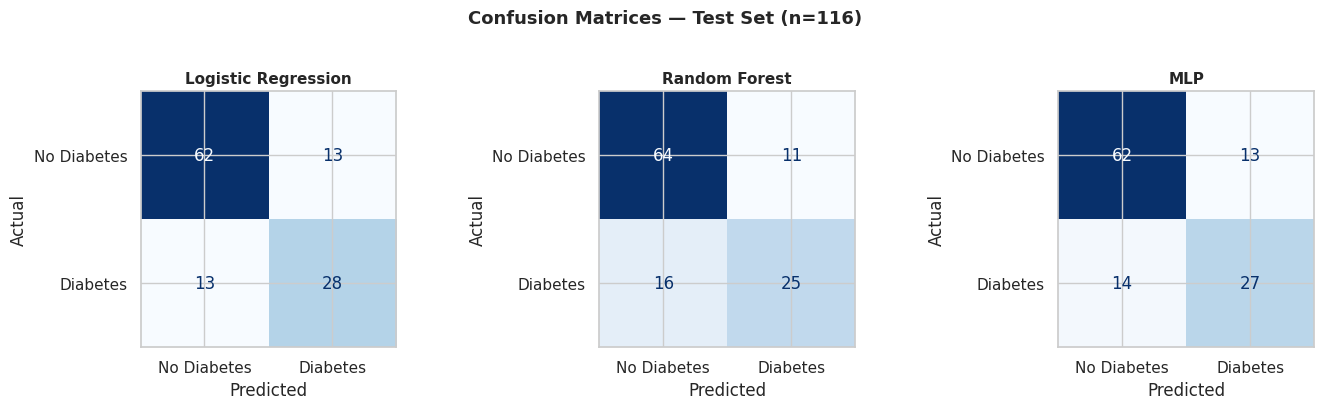

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
model_pairs = [
    ("Logistic Regression", lr_pred),
    ("Random Forest",       rf_pred),
    ("MLP",                 mlp_pred),
]

for ax, (name, pred) in zip(axes, model_pairs):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Diabetes", "Diabetes"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Test Set (n=116)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrices_combined.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. ROC Curves

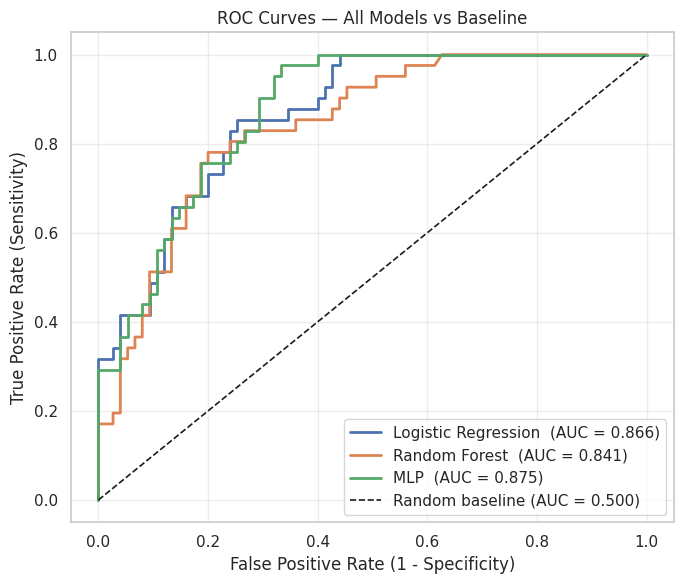

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, y_prob, color in [
    ("Logistic Regression", lr_prob,  "#4C72B0"),
    ("Random Forest",       rf_prob,  "#DD8452"),
    ("MLP",                 mlp_prob, "#55A868"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random baseline (AUC = 0.500)")
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC Curves — All Models vs Baseline")
ax.legend(loc="lower right")
ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("../outputs/figures/roc_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Model Comparison — Bar Chart

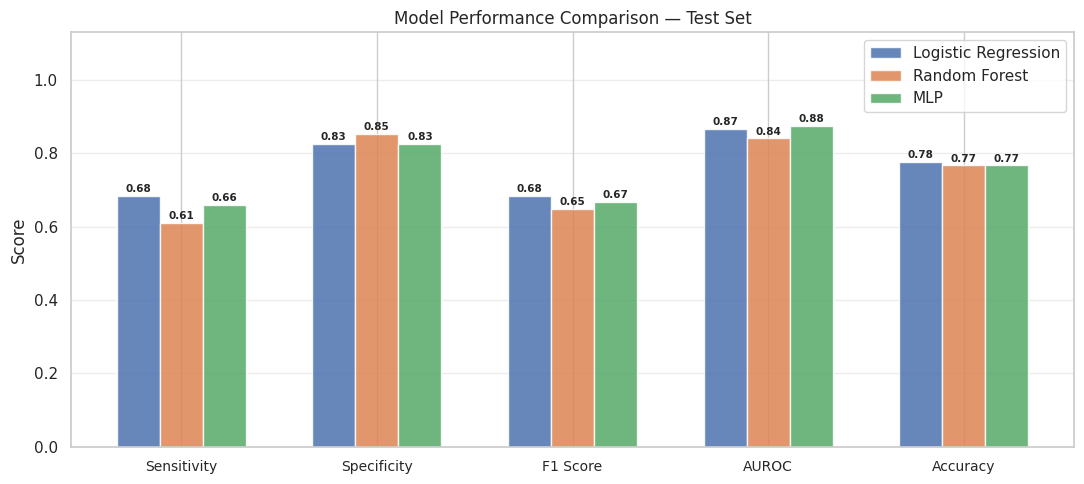

In [9]:
metrics_to_plot = ["Sensitivity", "Specificity", "F1 Score", "AUROC", "Accuracy"]
model_names = ["Logistic Regression", "Random Forest", "MLP"]
colors      = ["#4C72B0", "#DD8452", "#55A868"]

x = np.arange(len(metrics_to_plot))
width = 0.22

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model, color) in enumerate(zip(model_names, colors)):
    vals = [results_df.loc[model, m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color,
                  alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.set_ylim(0, 1.13)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison — Test Set")
ax.legend()
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.savefig("../outputs/figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Feature Importance (Random Forest)

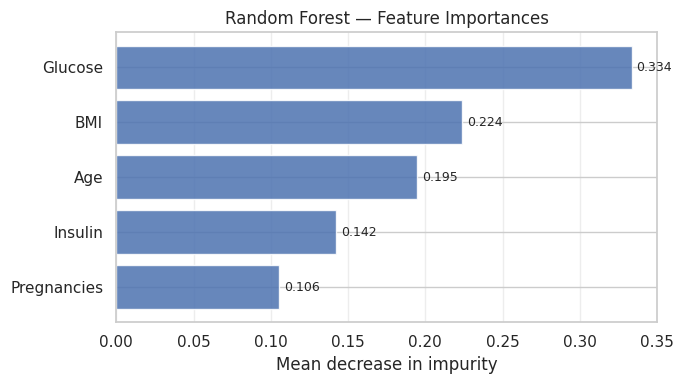

In [10]:
importances = rf.feature_importances_
indices     = np.argsort(importances)
sorted_feats = [features[i] for i in indices]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(sorted_feats, importances[indices], color="#4C72B0",
               edgecolor="white", alpha=0.85)
for bar, val in zip(bars, importances[indices]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest — Feature Importances")
ax.grid(axis="x", alpha=0.35)
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Glucose** is by far the most important feature, accounting for roughly 30–40% of the
model's decision-making. This aligns with clinical practice — plasma glucose is the
primary biomarker used for diabetes diagnosis. **BMI** and **Age** follow, which is again
consistent with the known risk factors for Type 2 diabetes.

## 9. Classification Reports (Full Detail)

In [11]:
for name, pred in [("Logistic Regression", lr_pred), ("Random Forest", rf_pred), ("MLP", mlp_pred)]:
    print(f"{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, pred, target_names=["No Diabetes", "Diabetes"]))
    m = [m for m in [lr_metrics, rf_metrics, mlp_metrics] if m["Model"] == name][0]
    print(f"  Confusion matrix:  TP={m['TP']}  FN={m['FN']}  FP={m['FP']}  TN={m['TN']}")
    print()

 Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.83      0.83      0.83        75
    Diabetes       0.68      0.68      0.68        41

    accuracy                           0.78       116
   macro avg       0.75      0.75      0.75       116
weighted avg       0.78      0.78      0.78       116

  Confusion matrix:  TP=28  FN=13  FP=13  TN=62

 Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.80      0.85      0.83        75
    Diabetes       0.69      0.61      0.65        41

    accuracy                           0.77       116
   macro avg       0.75      0.73      0.74       116
weighted avg       0.76      0.77      0.76       116

  Confusion matrix:  TP=25  FN=16  FP=11  TN=64

 MLP
              precision    recall  f1-score   support

 No Diabetes       0.82      0.83      0.82        75
    Diabetes       0.68      0.66      0.67        41

    accuracy                           0.77

## 10. Saving Results

In [12]:
import json
from pathlib import Path

skip = {"Model", "TP", "TN", "FP", "FN"}
report = {}
for key, metrics in [("logistic_regression", lr_metrics), ("random_forest", rf_metrics), ("mlp", mlp_metrics)]:
    report[key] = {k.lower().replace(" ", "_"): v for k, v in metrics.items() if k not in skip}

report_path = Path("../outputs/reports/evaluation_results.json")
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(json.dumps(report, indent=2))
print(f"Saved: {report_path}")

Saved: ../outputs/reports/evaluation_results.json


## Summary & Clinical Interpretation

| Model | Sensitivity | Specificity | F1 | AUROC |
|-------|------------|------------|-----|-------|
| Logistic Regression | 0.683 | 0.827 | 0.683 | 0.866 |
| Random Forest | 0.610 | 0.853 | 0.649 | 0.841 |
| MLP | 0.659 | 0.827 | 0.667 | **0.875** |

All three models are meaningfully better than random. For a **screening** use case —
where the goal is to identify patients who should be sent for confirmatory testing —
the MLP or Logistic Regression would be preferred due to their higher sensitivity.
The Random Forest's higher specificity makes it more conservative, which is better
when follow-up tests are expensive or invasive.

**Limitations to keep in mind:**
- The dataset is small (n=768) and demographically narrow (Pima women only),
  so these results may not transfer to other populations.
- Insulin and SkinThickness have substantial missing data (~30–49%); median imputation
  is simple and may not fully capture the true distribution.
- None of the models have been probability-calibrated — the raw predicted probabilities
  should not be used as clinical risk estimates without further validation.